# Q-Learning on CartPole 

## What is CartPole?

CartPole can be modeled as a Markov decision process (MDP)

$$
(\mathcal{S}, \mathcal{A}, P, R, \gamma),
$$

where the state is typically

$$
s_t = \bigl(x_t, \dot{x}_t, \theta_t, \dot{\theta}_t\bigr),
$$

with $x_t$ the cart position, $\dot{x}_t$ the cart velocity, $\theta_t$ the pole angle, and $\dot{\theta}_t$ the pole angular velocity.

The action space is discrete:

$$
\mathcal{A} = \{\text{left},\,\text{right}\},
$$

which can also be written as $a_t \in \{-1, +1\}$ when using a signed force convention. At each time step, the agent applies a force $F_t$ to the cart, and the environment evolves according to the following nonlinear dynamics of the cart-pole system:

$$
\ddot{x}_t = \frac{F_t + m_p \sin(\theta_t) \bigl(l \dot{\theta}_t^2 + g \cos(\theta_t)\bigr)}{m_c + m_p \sin^2(\theta_t)}
$$

$$
\ddot{\theta}_t = \frac{-F_t \cos(\theta_t) - m_p l \dot{\theta}_t^2 \sin(\theta_t) \cos(\theta_t) - (m_c + m_p) g \sin(\theta_t)}{l (m_c + m_p \sin^2(\theta_t))}
$$

where $m_c$ is the mass of the cart, $m_p$ is the mass of the pole, $l$ is the length of the pole, and $g$ is the acceleration due to gravity.

The control objective is to keep the pole balanced near the upright position $\theta = 0$ while keeping the cart near the track center. A standard reward choice is

$$
r_t = 1
$$

for every step before termination. An episode ends when the cart leaves the allowed position range or when the pole angle exceeds a threshold.

For Q-learning, the action-value function $Q(s,a)$ is updated by

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha
\Bigl(r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Bigr),
$$

where $\alpha$ is the learning rate and $\gamma$ is the discount factor.

In [2]:
import gymnasium as gym
import numpy as np

## Tabular Q-learning setup

The continuous CartPole state is discretized into bins so we can use a tabular Q-table. This keeps the implementation simple and makes the update rule match the standard Q-learning equation.

In [3]:
def build_bins(num_bins: int = 12):
    """Create discretization bins for CartPole observations."""
    return [
        np.linspace(-4.8, 4.8, num_bins - 1), # Cart position
        np.linspace(-3.0, 3.0, num_bins - 1), # Cart velocity
        np.linspace(-0.418, 0.418, num_bins - 1), # Pole angle
        np.linspace(-3.5, 3.5, num_bins - 1), # Pole angular velocity
    ]

In [4]:
# Discretize the continuous state into a tuple of bin indices
def discretize_state(observation: np.ndarray, bins):
    return tuple(np.digitize(observation[i], bins[i]) for i in range(len(observation)))

# Epsilon-greedy action selection
def choose_action(state, q_table: np.ndarray, epsilon: float, rng: np.random.Generator):
    if rng.random() < epsilon:
        return int(rng.integers(q_table.shape[-1]))
    return int(np.argmax(q_table[state]))


In [5]:
# Main Q-learning training loop
def train_q_learning(
    episodes: int = 5000,
    max_steps: int = 500,
    learning_rate: float = 0.1,
    discount: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_min: float = 0.02,
    epsilon_decay: float = 0.995,
    num_bins: int = 12,
    seed: int = 42,
):
    env = gym.make("CartPole-v1")
    rng = np.random.default_rng(seed)
    bins = build_bins(num_bins) # Create discretization bins for CartPole observations

    obs_dim = env.observation_space.shape[0] # Number of state dimensions (4 for CartPole)
    action_dim = env.action_space.n
    q_table = np.zeros((num_bins,) * obs_dim + (action_dim,), dtype=np.float32) # Q-table with shape (num_bins, num_bins, num_bins, num_bins, action_dim)

    epsilon = epsilon_start
    episode_rewards = [] # Track total rewards per episode for monitoring training progress

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        state = discretize_state(observation, bins)
        total_reward = 0.0

        for _ in range(max_steps):
            action = choose_action(state, q_table, epsilon, rng)
            next_observation, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_state(next_observation, bins)

            best_next_q = float(np.max(q_table[next_state]))
            td_target = reward if done else reward + discount * best_next_q
            td_error = td_target - q_table[state + (action,)]
            q_table[state + (action,)] += learning_rate * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (episode + 1) % 250 == 0:
            recent_avg = np.mean(episode_rewards[-100:])
            print(
                f"Episode {episode + 1:4d} | "
                f"epsilon={epsilon:.4f} | "
                f"avg_reward(last100)={recent_avg:.2f}"
            )

    env.close()
    return q_table, bins, episode_rewards


In [6]:
# Train the Q-learning agent and get the learned Q-table, bins, and rewards history
q_table, bins, rewards = train_q_learning()
print("Training completed.")
print(f"Average reward over last 100 episodes: {np.mean(rewards[-100:]):.2f}")

Episode  250 | epsilon=0.2856 | avg_reward(last100)=30.15
Episode  500 | epsilon=0.0816 | avg_reward(last100)=66.29
Episode  750 | epsilon=0.0233 | avg_reward(last100)=59.11
Episode 1000 | epsilon=0.0200 | avg_reward(last100)=119.91
Episode 1250 | epsilon=0.0200 | avg_reward(last100)=125.99
Episode 1500 | epsilon=0.0200 | avg_reward(last100)=134.14
Episode 1750 | epsilon=0.0200 | avg_reward(last100)=98.28
Episode 2000 | epsilon=0.0200 | avg_reward(last100)=112.72
Episode 2250 | epsilon=0.0200 | avg_reward(last100)=127.92
Episode 2500 | epsilon=0.0200 | avg_reward(last100)=147.67
Episode 2750 | epsilon=0.0200 | avg_reward(last100)=120.40
Episode 3000 | epsilon=0.0200 | avg_reward(last100)=175.70
Episode 3250 | epsilon=0.0200 | avg_reward(last100)=135.25
Episode 3500 | epsilon=0.0200 | avg_reward(last100)=131.14
Episode 3750 | epsilon=0.0200 | avg_reward(last100)=127.11
Episode 4000 | epsilon=0.0200 | avg_reward(last100)=145.99
Episode 4250 | epsilon=0.0200 | avg_reward(last100)=159.82
E

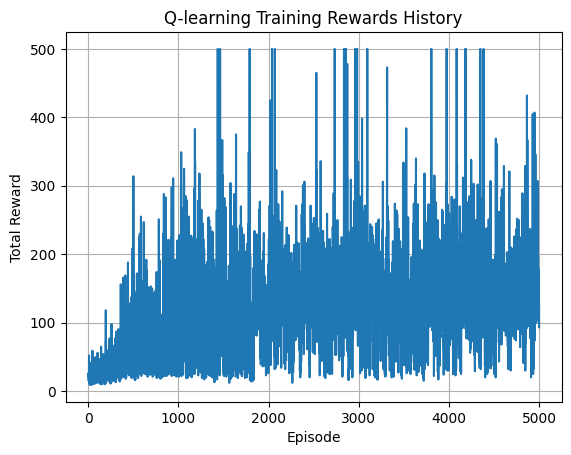

In [7]:
# plotting the rewards history
import matplotlib.pyplot as plt
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Rewards History")
plt.grid() 

In [8]:
# Evaluate the learned policy
def evaluate_policy(
    q_table: np.ndarray,
    bins,
    episodes: int = 10,
    max_steps: int = 500,
    render: bool = False,
    seed: int = 2026,
):
    env = gym.make("CartPole-v1", render_mode="human" if render else None) # Create environment with optional rendering for visualization during evaluation 
    rewards = []

    for episode in range(episodes):
        observation, _ = env.reset(seed=seed + episode)
        state = discretize_state(observation, bins)
        total_reward = 0.0

        for _ in range(max_steps):
            action = int(np.argmax(q_table[state]))
            observation, reward, terminated, truncated, _ = env.step(action)
            state = discretize_state(observation, bins)
            total_reward += reward

            if terminated or truncated:
                break

        rewards.append(total_reward)

    env.close()
    return float(np.mean(rewards)), rewards


In [9]:
avg_reward, eval_rewards = evaluate_policy(q_table, bins)

In [10]:
print(f"Evaluation average reward: {avg_reward:.2f}")
print(f"Evaluation rewards: {eval_rewards}")
    

Evaluation average reward: 116.50
Evaluation rewards: [129.0, 117.0, 99.0, 171.0, 96.0, 104.0, 109.0, 125.0, 108.0, 107.0]
